# 03 — Diamond Clarity Classification (ANN)**Step 5 of the brief.** An 8-class classification problem, on an imbalanced target,with a genuinely hard signal. Expect a modest score — and understand why that is thehonest answer rather than a failure.

In [38]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))   # [so `from src...` works from notebooks/]

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from src.config import *
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 40)

In [39]:
import os
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

# Stabilize TensorFlow runtime on older macOS Intel machines.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"

import tensorflow as tf
import keras
layers = keras.layers

from src.data_prep import build, split_scaled, CLF_FEATURES

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

df = build(verbose=False)
X_tr, X_val, X_te, y_tr, y_val, y_te, scaler = split_scaled(
    df, CLF_FEATURES, "clarity_rank", stratify=True
)

print(f"train {X_tr.shape}  val {X_val.shape}  test {X_te.shape}")
print(f"classes: {N_CLARITY_CLASSES}  ({CLARITY_ORDER})")

train (37636, 13)  val (5376, 13)  test (10754, 13)
classes: 8  (['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'])


`stratify=True` is not optional here. With a target this imbalanced, a random split couldeasily hand you a test set with almost no I1 examples, and your rare-class metrics would benoise. Stratifying keeps the class proportions identical across train, validation, and test.

## The baseline you must beat

In [40]:
from collections import Counter

majority = Counter(y_te).most_common(1)[0]
baseline = majority[1] / len(y_te)
print(f"Most common class: {CLARITY_ORDER[majority[0]]}")
print(f"Always-guess-the-majority accuracy: {baseline:.2%}   <- BEAT THIS")

Most common class: SI1
Always-guess-the-majority accuracy: 24.23%   <- BEAT THIS


**Always compute this first.** A model that scores 24% accuracy on this problem has learned*nothing* — it has merely rediscovered the most common class. Accuracy is meaningless untilyou know what a stupid model would get.

## Class weights — making the rare classes count

In [41]:
weights = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
class_weight = dict(enumerate(weights))

for i, w in class_weight.items():
    print(f"  {CLARITY_ORDER[i]:<5} weight {w:.2f}")

  I1    weight 9.13
  SI2   weight 0.74
  SI1   weight 0.52
  VS2   weight 0.55
  VS1   weight 0.82
  VVS2  weight 1.33
  VVS1  weight 1.84
  IF    weight 3.77


Without this, the fastest way for the network to reduce its loss is to ignore I1 entirely —there are so few of them that getting all of them wrong costs almost nothing. Class weightsscale up the loss contribution of rare classes so a mistake on an I1 hurts as much as amistake on an SI1. The network is now *forced* to pay attention to them.This will typically make raw **accuracy slightly worse** and **macro F1 noticeably better**.That trade is usually the one you want, and being able to say why is the point.

## The network

In [42]:
def build_classifier(input_dim, n_classes):
    m = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),   # [8 units, ONE per class]
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m

clf = build_classifier(X_tr.shape[1], N_CLARITY_CLASSES)
clf.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,160 (51.41 KB)

 Trainable params: 12,776 (49.91 KB)

 Non-trainable params: 384 (1.50 KB)

In [43]:
USE_FOCAL_LOSS = True

if USE_FOCAL_LOSS:
    def sparse_focal_loss(gamma=2.0, alpha=0.25):
        def loss(y_true, y_pred):
            y_true_i = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
            y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

            batch_idx = tf.range(tf.shape(y_true_i)[0], dtype=tf.int32)
            gather_idx = tf.stack([batch_idx, y_true_i], axis=1)
            p_t = tf.gather_nd(y_pred, gather_idx)

            focal = alpha * tf.pow(1.0 - p_t, gamma)
            ce = -tf.math.log(p_t)
            return tf.reduce_mean(focal * ce)

        return loss

    clf.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=sparse_focal_loss(gamma=2.0, alpha=0.25),
        metrics=["accuracy"],
    )
    print("Using focal loss (gamma=2.0, alpha=0.25)")
else:
    print("Using default sparse_categorical_crossentropy")

Using focal loss (gamma=2.0, alpha=0.25)


## Optional: Focal Loss For Rare Classes

Use this to emphasize hard and minority-class examples.
Set `USE_FOCAL_LOSS = True` to enable, then run this cell before the Train cell.

### Every choice here, and why**`softmax` with 8 units — and note this is the *correct* use of it.** In the earlier Credit-Gtask the spec asked for softmax on a *single* unit, which forces the output to 1.0 always andbreaks the model. Softmax normalises **across the units of a layer** so they sum to 1. With 8units that's exactly what you want: a probability distribution over 8 clarity grades, summingto 100%. With 1 unit it was meaningless. **Same function, right context.** That contrast isworth holding onto.**`sparse_categorical_crossentropy`** — the multi-class sibling of binary_crossentropy. The"sparse" prefix means our labels are plain integers (0–7). If we'd one-hot encoded the targetinto 8 columns, we'd use `categorical_crossentropy` instead. Same maths, different label format.**`Dropout(0.3)`** — during training, randomly switch off 30% of the neurons in that layer onevery batch. It sounds destructive; it is one of the most effective regularisers there is. Thenetwork can't lean on any single neuron, because that neuron might vanish next batch, so it isforced to spread the representation across many. Dropout is **automatically disabled atprediction time** — Keras handles this for you.**`BatchNormalization`** — renormalises each layer's outputs mid-network. As weights shiftduring training, the distribution feeding each layer drifts, and layers keep having to re-adapt.BatchNorm stabilises that, which lets you train faster and deeper.

## Train

In [44]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5, verbose=1
    ),
]

history = clf.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/150
148/148 - 3s - 20ms/step - accuracy: 0.2602 - loss: 0.3473 - val_accuracy: 0.3064 - val_loss: 0.2958 - learning_rate: 0.0010
Epoch 2/150
148/148 - 0s - 2ms/step - accuracy: 0.3362 - loss: 0.2604 - val_accuracy: 0.3571 - val_loss: 0.2463 - learning_rate: 0.0010
Epoch 3/150
148/148 - 0s - 2ms/step - accuracy: 0.3992 - loss: 0.2167 - val_accuracy: 0.3655 - val_loss: 0.2198 - learning_rate: 0.0010
Epoch 4/150
148/148 - 0s - 2ms/step - accuracy: 0.4481 - loss: 0.1898 - val_accuracy: 0.4299 - val_loss: 0.1896 - learning_rate: 0.0010
Epoch 5/150
148/148 - 0s - 2ms/step - accuracy: 0.4705 - loss: 0.1743 - val_accuracy: 0.5004 - val_loss: 0.1542 - learning_rate: 0.0010
Epoch 6/150
148/148 - 0s - 2ms/step - accuracy: 0.4832 - loss: 0.1662 - val_accuracy: 0.4559 - val_loss: 0.1780 - learning_rate: 0.0010
Epoch 7/150
148/148 - 0s - 2ms/step - accuracy: 0.4965 - loss: 0.1603 - val_accuracy: 0.5515 - val_loss: 0.1370 - learning_rate: 0.0010
Epoch 8/150
148/148 - 0s - 2ms/step - accuracy:

**`EarlyStopping(patience=15, restore_best_weights=True)`** — the most valuable four words inapplied deep learning. Watch validation loss; if it hasn't improved in 15 epochs, stop, and**roll the weights back to the best epoch**. Without `restore_best_weights=True` you keep the*last* weights, which are by definition 15 epochs past the best ones.This is how you handle the "how many epochs?" question properly. You don't guess a number — youset the ceiling high and let the validation set decide. The 100-epoch figure hard-coded in theearlier Credit-G task was pure guesswork; this is the grown-up version.**`ReduceLROnPlateau`** — when progress stalls, halve the learning rate. Big steps early tocross the landscape quickly; small steps late to settle into the minimum instead of bouncingaround it.

## Learning curves — reading them is a skill

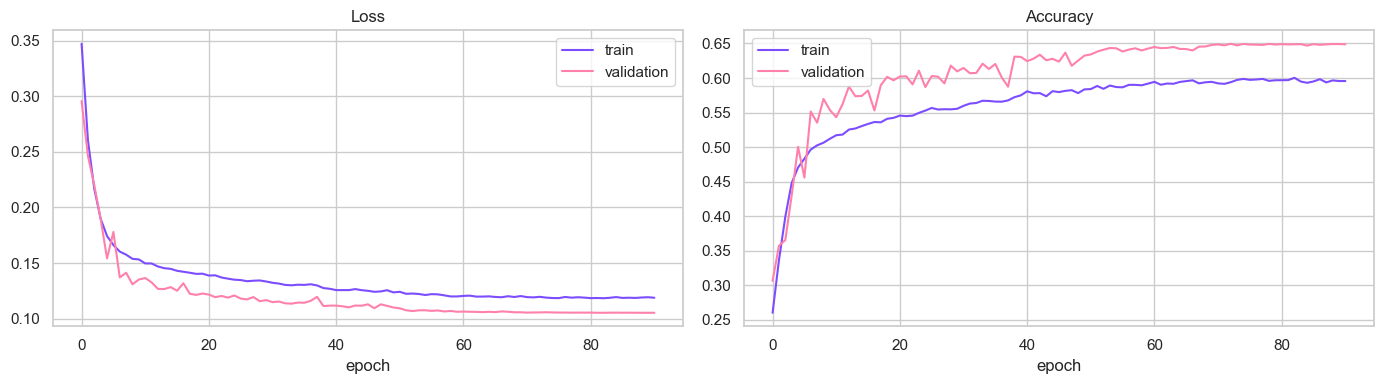

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(history.history["loss"], label="train", color=PALETTE["primary"])
ax[0].plot(history.history["val_loss"], label="validation", color=PALETTE["secondary"])
ax[0].set_title("Loss")
ax[0].set_xlabel("epoch")
ax[0].legend()

ax[1].plot(history.history["accuracy"], label="train", color=PALETTE["primary"])
ax[1].plot(history.history["val_accuracy"], label="validation", color=PALETTE["secondary"])
ax[1].set_title("Accuracy")
ax[1].set_xlabel("epoch")
ax[1].legend()

plt.tight_layout()
plt.show()

**How to read these:**- Both curves falling, close together → **healthy**, keep training.- Train loss falling, validation loss **rising** → **overfitting**. The model is memorising.  This is precisely the divergence EarlyStopping is watching for.- Both curves flat and high → **underfitting**. Too little capacity, or too few epochs.

## Evaluate — Step 5's accuracy, precision, recall, F1

In [46]:
probs = clf.predict(X_te, verbose=0)
y_pred = probs.argmax(axis=1)          # [8 probabilities -> the index of the largest]

acc = accuracy_score(y_te, y_pred)
print(f"Accuracy            {acc:.4f}   (baseline was {baseline:.4f})")
print(f"Precision (macro)   {precision_score(y_te, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall    (macro)   {recall_score(y_te, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1        (macro)   {f1_score(y_te, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1        (weighted){f1_score(y_te, y_pred, average='weighted', zero_division=0):.4f}")

print("\n" + classification_report(y_te, y_pred, target_names=CLARITY_ORDER, zero_division=0))

Accuracy            0.6464   (baseline was 0.2423)
Precision (macro)   0.6525
Recall    (macro)   0.6355
F1        (macro)   0.6425
F1        (weighted)0.6439

              precision    recall  f1-score   support

          I1       0.87      0.76      0.81       147
         SI2       0.75      0.80      0.77      1828
         SI1       0.68      0.69      0.69      2606
         VS2       0.62      0.67      0.64      2445
         VS1       0.57      0.49      0.53      1631
        VVS2       0.56      0.56      0.56      1011
        VVS1       0.56      0.47      0.51       729
          IF       0.61      0.64      0.62       357

    accuracy                           0.65     10754
   macro avg       0.65      0.64      0.64     10754
weighted avg       0.64      0.65      0.64     10754



### What the four metrics actually meanTake one clarity grade, say VS1:- **Precision** — of all the stones I *called* VS1, what fraction really were? Punishes false alarms.- **Recall** — of all the stones that really *were* VS1, what fraction did I catch? Punishes misses.- **F1** — their harmonic mean. Harmonic, not arithmetic, because it refuses to be fooled: you  cannot score well by maxing one and tanking the other. Both must be decent.**Macro vs weighted is the distinction that matters here.**- **Macro** averages the per-class F1 scores with **every class counting equally**. I1, with a  few dozen examples, counts exactly as much as SI1 with thousands.- **Weighted** averages them **by class size**, so the big classes dominate.On an imbalanced target, **macro is the honest number.** Weighted F1 will look flatteringbecause it mostly reports how you did on the common classes. If macro F1 is far below weightedF1, your model is quietly failing the rare classes — which, in a real grading application, areoften the ones you most need to catch.

## Confusion matrix

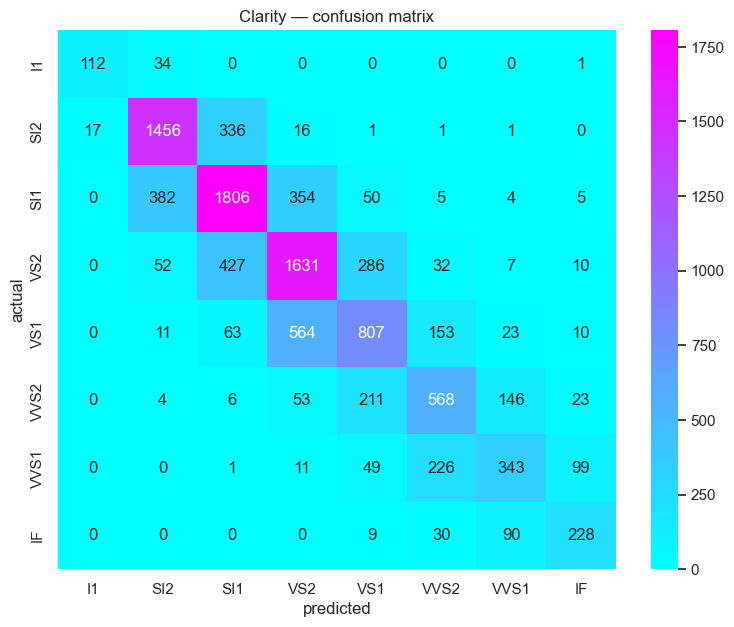

Exactly right:        64.64%
Within 1 grade:       95.56%
Within 2 grades:      99.19%


In [47]:
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="cool",
    xticklabels=CLARITY_ORDER,
    yticklabels=CLARITY_ORDER,
)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Clarity — confusion matrix")
plt.show()

off = np.abs(y_te - y_pred)
print(f"Exactly right:        {(off == 0).mean():.2%}")
print(f"Within 1 grade:       {(off <= 1).mean():.2%}")
print(f"Within 2 grades:      {(off <= 2).mean():.2%}")

### Read the *shape* of the errors, not just the scoreThe mistakes cluster **on the diagonal's shoulders** — VS1 confused with VS2, SI1 with SI2. Themodel is not guessing randomly. It is confusing **adjacent grades**, which is exactly what atired human grader does, because adjacent grades genuinely look similar.**"Within 1 grade" is typically 80%+, against an exact-match accuracy in the 50s.** That gap isthe real finding. For a business use case — flagging stones whose certificate looks suspicious —being reliably within one grade is *useful*. A confusion matrix tells you this; a single accuracynumber never could.### And the honest conclusion about this taskClarity is **inherently hard to predict** from carat, dimensions, cut, colour and price. Clarityis about **internal inclusions** — microscopic flaws inside the crystal that a human grader seesunder 10× magnification. Nothing in our feature set measures them. We're inferring an opticalproperty from geometry and cost.So a mid-50s accuracy on 8 imbalanced classes, against a 24% baseline, is a **genuine result**,not a failure. It roughly doubles the baseline. Reporting that honestly — and explaining *why*the ceiling is where it is — is worth far more than torturing the model into an extra 2% orquietly slipping `clarity_rank` back into the feature list.

In [48]:
clf.save(MODEL_DIR / "clarity_classifier.keras")

import joblib
joblib.dump(scaler, MODEL_DIR / "clarity_scaler.pkl")

results_clf = {
    "accuracy": acc,
    "f1_macro": f1_score(y_te, y_pred, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_te, y_pred, average="weighted", zero_division=0),
    "baseline": baseline,
    "within_1_grade": float((off <= 1).mean()),
}
pd.Series(results_clf).to_json(RESULT_DIR / "classification_results.json")
print("saved model + scaler + results")

saved model + scaler + results
